In [1]:
import yfinance as yf
import pandas as pd
import pandas_ta as ta
import numpy as np
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated,List
from langchain_groq import ChatGroq
from pydantic import BaseModel, Field
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage,HumanMessage, AIMessage,SystemMessage,ToolMessage
from dotenv import load_dotenv
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode,  tools_condition 
import statistics
import requests
import re
import json

In [2]:
@tool
def get_company_info(ticker: str) -> dict:
    """Get current price, EPS, book value, and sector for valuation."""
    info = yf.Ticker(ticker).info
    return {
        "current_price":      info.get("currentPrice"),
        "sector":             info.get("sector"),
        "eps":                info.get("trailingEps"),
        "book_value":         info.get("bookValue"),       
        "market_cap":         info.get("marketCap"),
        "forward_pe":         info.get("forwardPE"),
        "beta":               info.get("beta"), 
    }

In [3]:

@tool
def get_dcf_inputs(ticker: str) -> dict:
    """Fetch FCF history, revenue growth for DCF model."""
    stock      = yf.Ticker(ticker)
    info       = stock.info
    cashflow   = stock.cashflow

    # last 3 years FCF
    fcf_history = {}
    for col in cashflow.columns[:3]:
        op_cf = cashflow.loc["Operating Cash Flow", col] if "Operating Cash Flow" in cashflow.index else None
        capex = cashflow.loc["Capital Expenditure", col] if "Capital Expenditure" in cashflow.index else None
        if op_cf and capex:
            fcf_history[str(col.year)] = float(op_cf + capex)

    # revenue growth (YoY)
    rev_growth = info.get("revenueGrowth") or 0.08

    # beta
    beta = info.get("beta", 1.0)

    return {
        "fcf_history":   fcf_history,
        "revenue_growth": round(rev_growth, 4),
        "ebitda":        info.get("ebitda"),
        "shares_outstanding": info.get("sharesOutstanding"),
        "total_debt":    info.get("totalDebt"),
        "cash":          info.get("totalCash"),
    }

In [4]:
@tool
def get_peer_multiples(peer_company: list) -> dict:
    """Fetch PE, PB, EV/EBITDA for a list of peer tickers and compute sector medians."""
    session = requests.Session()
    session.headers.update({
                "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
            })
    peers = {}
    for company in peer_company:
        search = yf.Search(company, max_results=1, session=session)
        detected_ticker = search.quotes[0]['symbol']
        info   = yf.Ticker(detected_ticker).info
        ev     = info.get("enterpriseValue")
        ebitda = info.get("ebitda")

        peers[company] = {
            "company_ticker": detected_ticker,
            "pe_ratio":  info.get("trailingPE"),
            "pb_ratio":  info.get("priceToBook"),
            "ev_ebitda": round(ev / ebitda, 2) if ev and ebitda else None,
        }
    
    pe_list  = [p["pe_ratio"]  for p in peers.values() if p["pe_ratio"]]
    pb_list  = [p["pb_ratio"]  for p in peers.values() if p["pb_ratio"]]
    ev_list  = [p["ev_ebitda"] for p in peers.values() if p["ev_ebitda"]]
    
    median_pe = statistics.median(pe_list) if pe_list else None
    median_pb = statistics.median(pb_list) if pb_list else None
    median_ev_ebitda = statistics.median(ev_list) if ev_list else None

    return {
        "peers":            peers,
        "median_pe":        median_pe,
        "median_pb":        median_pb,
        "median_ev_ebitda": median_ev_ebitda
    }

In [5]:
load_dotenv()

llm = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct", # Or any other valid Groq identifier
    temperature=0.0,
    max_retries=2,
)
report_writer_llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.0,
)

In [6]:
class valuationState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    ticker: str
    computed_valuations : dict
    result: str

In [7]:
REPORT_SYSTEM_PROMPT = """You are a valuation analyst. You will receive pre-computed valuation numbers. Do NOT recompute anything — the math has already been done in Python. Your job is to structure the output and write the summary.

You will receive these pre-computed fields:
- current_price, comps_target, dcf_target, graham_number
- price_target, upside_pct, verdict, wacc_used, confidence, methods_used

Precomputed fields:
{computed_valuations}

Return ONLY this JSON:
{
  "ticker": str,
  "current_price": float,
  "price_target": float,
  "upside_pct": float,
  "verdict": "Undervalued" | "Fairly Valued" | "Overvalued",
  "peers_used": [str],
  "comps_target": float or null,
  "dcf_target": float or null,
  "graham_number": float or null,
  "median_pe": float or null,
  "confidence": float,
  "summary": str (4 - 6 sentences: state the price target, the upside/downside percentage, and most important reason for the verdict — e.g. strong FCF growth, peer multiple compression, or conservative Graham floor)
}

Use the EXACT numbers provided. Do not estimate, round differently, or recalculate. Return ONLY valid JSON. No markdown fences, no extra text

"""
def report_node(state: valuationState) -> valuationState:
    computed = state.get("computed_valuations", {})

    formatted_prompt = REPORT_SYSTEM_PROMPT.replace(
        "{computed_valuations}",
        json.dumps(computed, indent=2)
    )

    messages = [
        SystemMessage(content=formatted_prompt),
        HumanMessage(content="Write the ValuationReport JSON now."),
    ]

    response = report_writer_llm.invoke(messages)

    return {"messages": [response], "result":response.content}

In [8]:
valuation_tools = [get_peer_multiples,get_dcf_inputs,get_company_info]
valuation_tools_node = ToolNode(valuation_tools)
valuation_tools_llm = llm.bind_tools(valuation_tools)

In [9]:
def ValuationAgent(state:valuationState)->valuationState:
    response = valuation_tools_llm.invoke(state["messages"])
    return {"messages": [response]}


In [10]:
def compute_val_node(state: valuationState) -> valuationState:
    messages = state['messages']
    data = {}
    for msg in messages:
        if isinstance(msg, ToolMessage):
            try:
                data[msg.name] = json.loads(msg.content)
            except json.JSONDecodeError:
                continue

    company = data.get("get_company_info", {})
    peers   = data.get("get_peer_multiples", {})
    dcf     = data.get("get_dcf_inputs", {})

    def safe(value, default):
        """.get() only falls back when the key is missing — not when the
        value is explicitly None. These tools often store None, so guard both."""
        return value if value is not None else default

    eps            = safe(company.get("eps"), 0)
    book_value     = safe(company.get("book_value"), 0)
    current_price  = safe(company.get("current_price"), 0)
    median_pe      = safe(peers.get("median_pe"), 0)
    beta           = safe(company.get("beta"), 1.0)
    fcf_history    = safe(dcf.get("fcf_history"), {})
    revenue_growth = safe(dcf.get("revenue_growth"), 0.08)
    shares         = safe(dcf.get("shares_outstanding"), 0)   # 0, not 1 — see Bug 3
    debt           = safe(dcf.get("total_debt"), 0)
    cash           = safe(dcf.get("cash"), 0)

    risk_free = 0.045
    erp       = 0.055
    wacc      = round(risk_free + beta * erp, 4)

    # ── DCF ──
    dcf_target = None
    if fcf_history and shares > 0:
        latest_fcf = list(fcf_history.values())[0]
        g = min(float(revenue_growth), 0.20)   # cap restored

        pv_fcfs = 0
        for yr in range(1, 6):
            future_cash_flow = latest_fcf * (1 + g) ** yr
            pv_fcfs += future_cash_flow / (1 + wacc) ** yr

        perpetual_growth = 0.03
        if wacc > perpetual_growth:             # guards divide-by-zero / negative terminal value
            terminal    = (latest_fcf * (1 + g) ** 5 * (1 + perpetual_growth)) / (wacc - perpetual_growth)
            terminal_pv = terminal / (1 + wacc) ** 5
            equity      = pv_fcfs + terminal_pv - debt + cash
            dcf_target  = round(equity / shares, 2)

    # ── Comps ──
    comps_target = round(median_pe * eps, 2) if median_pe and eps else None

    # ── Graham ──
    graham = None
    if eps > 0 and book_value > 0:
        graham = round((22.5 * eps * book_value) ** 0.5, 2)

    # ── Weighted target ──
    methods = {"comps": comps_target, "dcf": dcf_target, "graham": graham}
    weights = {"comps": 0.40, "dcf": 0.40, "graham": 0.20}
    valid   = {k: v for k, v in methods.items() if v and v > 0}

    price_target = None
    if valid:
        total_w      = sum(weights[k] for k in valid)
        price_target = round(sum(v * weights[k] / total_w for k, v in valid.items()), 2)

    # ── Upside / verdict — 
    if price_target and current_price > 0:
        upside  = round((price_target - current_price) / current_price, 4)
        verdict = (
            "Undervalued"   if upside > 0.15  else
            "Overvalued"    if upside < -0.15 else
            "Fairly Valued"
        )
    else:
        upside  = None
        verdict = "Unknown — missing current price"

    confidence = round(len(valid) / 3, 2)

    computed_valuation = {
        "ticker":        state.get("ticker"),
        "current_price": current_price,
        "comps_target":  comps_target,
        "dcf_target":    dcf_target,
        "graham_number": graham,
        "median_pe":     median_pe,
        "peers_used":    list(peers.get("peers", {}).keys()),
        "price_target":  price_target,
        "upside_pct":    upside,
        "verdict":       verdict,
        "wacc_used":     wacc,
        "confidence":    confidence,
        "methods_used":  list(valid.keys()),
    }

    return {"computed_valuations": computed_valuation}

In [11]:
graph = StateGraph(valuationState)
graph.add_node("ValuationAgent",ValuationAgent)
graph.add_node("ValuationAgentTools",valuation_tools_node)
graph.add_node("compute_valuation",compute_val_node)
graph.add_node("ReportWriter",report_node)

graph.add_edge(START,"ValuationAgent")
graph.add_conditional_edges("ValuationAgent",tools_condition,{"tools": "ValuationAgentTools",END:"compute_valuation"})
graph.add_edge("ValuationAgentTools","ValuationAgent")
graph.add_edge("compute_valuation","ReportWriter")
graph.add_edge("ReportWriter",END)

workflow=graph.compile()

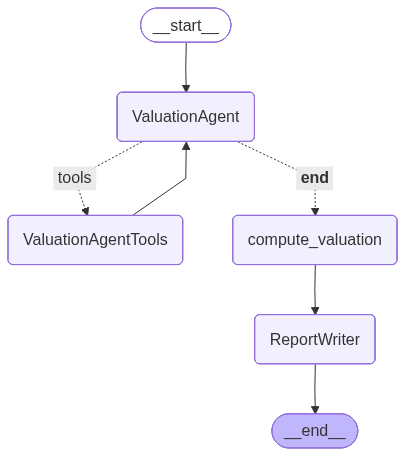

In [12]:
workflow

In [13]:
VALUATION_AGENT_SYS_PROMPT = """You are a financial data collector for valuation analysis.

Call ALL 3 tools in this order for ticker: {ticker}

STEP 1 — get_company_info("{ticker}")
Fetch current price, EPS, book value per share, sector, and beta.

STEP 2 — get_peer_multiples([list of 4 peer official company full names])
Select 4 peers from the SAME exchange and sector as {ticker}.


STEP 3 — get_dcf_inputs("{ticker}")
Fetch FCF history, revenue growth, shares outstanding, total debt, and cash.

Call all 3 tools before stopping. Do not write any analysis — just collect data."""




In [14]:
def parse_json_response(content: str) -> dict:
    """Strip markdown fences if present, then parse JSON."""
    match = re.search(r"```(?:json)?\s*(.*?)\s*```", content, re.DOTALL)
    if match:
        content = match.group(1)
    return json.loads(content.strip())

In [15]:
def run_Valuation_Agent(ticker:str)->dict:
    initial_state = {
        "messages": [
            SystemMessage(content=VALUATION_AGENT_SYS_PROMPT.format(ticker=ticker)),
            HumanMessage(content=f"Analyze the valuation of ticker: {ticker}")
        ],
        "ticker": ticker,
        "computed_valuations": {},
        "result": ""
    }


    return workflow.stream(initial_state)

In [22]:
a=run_Valuation_Agent("TCS.NS")

In [23]:
for event in a:
    print(event)
    for node_name, node_state in event.items():
        print(f"Node: {node_name}")
        print(f"Data: {node_state}")
        print("---")

{'ValuationAgent': {'messages': [AIMessage(content='## Step 1: Get Company Information\nFirst, I need to fetch the current price, EPS, book value per share, sector, and beta for TCS.NS.\n\n', additional_kwargs={'tool_calls': [{'id': 'xpvjgdd49', 'function': {'arguments': '{"ticker":"TCS.NS"}', 'name': 'get_company_info'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 290, 'prompt_tokens': 956, 'total_tokens': 1246, 'completion_time': 0.655715104, 'completion_tokens_details': None, 'prompt_time': 0.035329932, 'prompt_tokens_details': None, 'queue_time': 0.047258957, 'total_time': 0.691045036}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f2e23-7ddf-7e52-8ca7-9f6575c85c62-0', tool_calls=[{'name': 'get_company_info', 'args': {'ticker': 'TCS.NS'}, 'id': 'xpvjgdd49', 'type': 'tool_call'}]